# Objective 2 -- Productivity & Degradation: Plots

Reads the zonal-statistics and LandTrendr event-summary CSVs exported by
`productivity_degradation_landtrendr.ipynb` (downloaded from Drive into `outputs/tables/`) and
produces the highest-value trend/degradation plots called for in the Objective 2 plan (Sec.10,
14, 17, 18). No Earth Engine calls happen in this notebook -- it is a pure pandas/matplotlib/
seaborn post-processing step on already-exported tables, matching Objective 1's own plotting
notebook.

Plots are deliberately consolidated rather than one-per-plan-line-item (e.g. one combined
reference-normalized anomaly chart instead of three near-identical ones) to keep the set focused
on the clearest productivity/degradation signal, and to complement rather than duplicate the
LandTrendr disturbance/recovery rasters already exported (this notebook covers site-level
*trend* and *summary* evidence; the rasters cover *where*).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from eetools.visualization.plots import plot_single_metric_annually

import config

In [2]:
sns.set_theme(style="whitegrid")
config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SITE_ORDER = [s["site_id"] for s in config.SITES]
SITE_LABELS = {s["site_id"]: s["site_name"] for s in config.SITES}
REFERENCE_SITE = "mbokishi"  # intact reference site
COMPARISON_SITES = [s for s in SITE_ORDER if s != REFERENCE_SITE]
PERIOD_ORDER = list(config.PERIODS.keys())  # baseline, pre, current

## Load tables

Landsat is used for every core trend/anomaly/boxplot panel below -- it's the only sensor with a
full 1984-2025 record, matching the plan's own choice of Landsat for headline trend maps
(Sec.10.3) and keeping the line-chart evidence directly comparable to the LandTrendr rasters
(also built from Landsat). HLS/Sentinel-2 tables are available in `outputs/tables/` for future
sensor-specific or fine-scale follow-up (plan Sec.16.C: interpret sensor groups separately, don't
merge them) but aren't needed for the plots here.

In [3]:
landsat_ts = pd.read_csv(config.TABLES_DIR / "landsat_site_timeseries_annual_seasonal.csv")
landsat_period = pd.read_csv(config.TABLES_DIR / "landsat_site_summary_by_period.csv")
# Two independent LandTrendr runs (dry-season NBR, wet-season MSAVI2) -- see Plot 6.
landtrendr_nbrseg_summary = pd.read_csv(config.TABLES_DIR / "landtrendr_nbrseg_event_summary_by_site.csv")
landtrendr_msavi2seg_summary = pd.read_csv(config.TABLES_DIR / "landtrendr_msavi2seg_event_summary_by_site.csv")
chirps_annual = pd.read_csv(config.TABLES_DIR / "chirps_annual_rainfall_1984_2025.csv")

## Plots 1-3 -- Core productivity / moisture / bare-ground trends

Dry-season Landsat, 1984-2025, one representative metric per interpretation-framework theme:
MSAVI2 for productivity/sparse-grassland condition, NDMI for moisture/woody
condition, BSI for bare-ground degradation pressure. Median rather than mean 
(less sensitive to outliers). Some 1980s-90s dry-season windows have zero cloud-free Landsat 5
scenes over this small AOI (a real data gap, not a bug - see the notebook's own empty-window
guard); those years show as a genuine break in the line rather than an interpolated value.

In [4]:
def plot_site_index_trend(df: pd.DataFrame, value_col: str, ylabel: str, title: str, filename: str) -> None:
    """Line plot of one Landsat dry-season index metric by site, 1984-2025."""
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(
        data=df,
        x="year",
        y=value_col,
        hue="site_name",
        hue_order=[SITE_LABELS[s] for s in SITE_ORDER],
        marker="o",
        markersize=4,
        ax=ax,
    )
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title="Site")
    fig.tight_layout()
    fig.savefig(config.PLOTS_DIR / filename, dpi=200, bbox_inches="tight")


landsat_dry = landsat_ts[landsat_ts["season"] == "dry"].copy()
landsat_dry["site_name"] = landsat_dry["site_id"].map(SITE_LABELS)

### Plot 1 -- Productivity trend (MSAVI2)

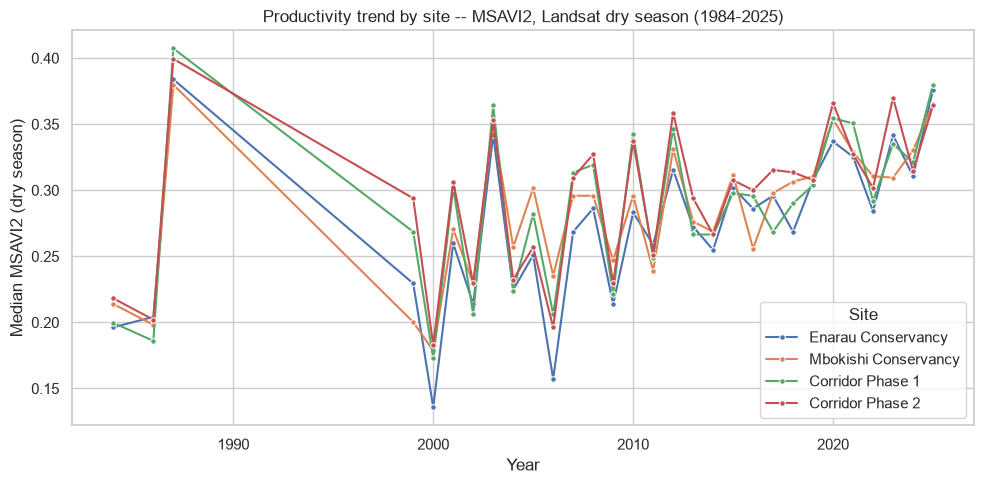

In [5]:
plot_site_index_trend(
    landsat_dry,
    "MSAVI2_median",
    "Median MSAVI2 (dry season)",
    "Productivity trend by site -- MSAVI2, Landsat dry season (1984-2025)",
    "trend_msavi2_by_site.png",
)

### Plot 2 -- Moisture / woody-condition trend (NDMI)

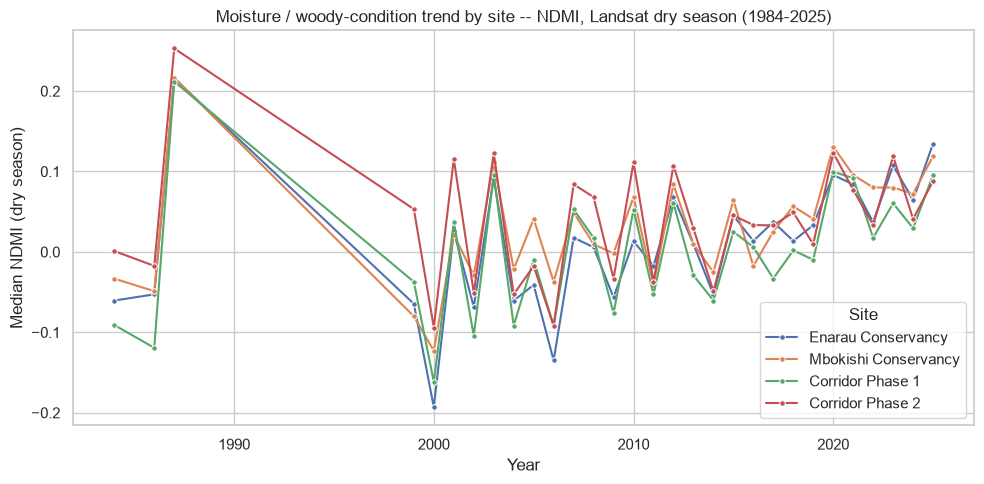

In [6]:
plot_site_index_trend(
    landsat_dry,
    "NDMI_median",
    "Median NDMI (dry season)",
    "Moisture / woody-condition trend by site -- NDMI, Landsat dry season (1984-2025)",
    "trend_ndmi_by_site.png",
)

### Plot 3 -- Bare-ground degradation-pressure trend (BSI)

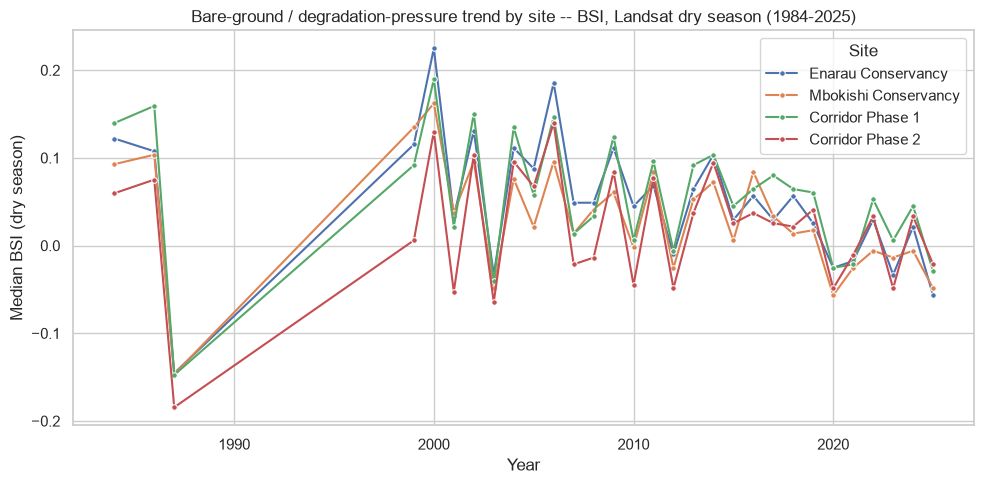

In [7]:
plot_site_index_trend(
    landsat_dry,
    "BSI_median",
    "Median BSI (dry season)",
    "Bare-ground / degradation-pressure trend by site -- BSI, Landsat dry season (1984-2025)",
    "trend_bsi_by_site.png",
)

## Plot 4 -- Reference-normalized MSAVI2 anomaly vs. Mbokishi

`site_relative_anomaly = site_metric - mbokishi_metric_same_year`- the
localized-degradation read: if a site tracks Mbokishi (near zero), the shared regional
rainfall/climate signal likely explains any shared trend; a site diverging from zero indicates
something happening locally rather than regionally. All three comparison sites combined on one
axis (rather than three near-identical separate charts) so their relative divergence is directly
comparable.

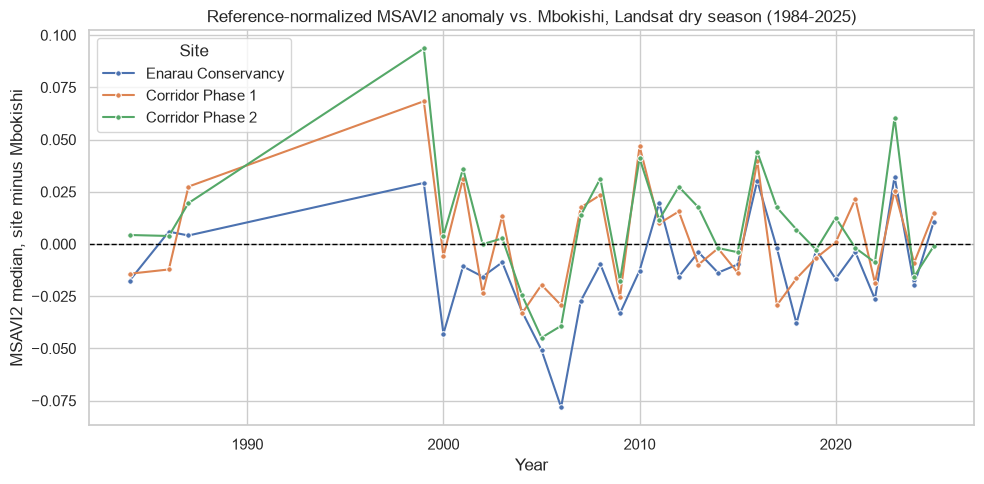

In [8]:
def build_relative_anomaly(df: pd.DataFrame, value_col: str, reference_site: str) -> pd.DataFrame:
    """Long-format site_metric - reference_site_metric_same_year (plan Sec.10.2)."""
    pivot = df.pivot(index="year", columns="site_id", values=value_col)
    anomaly = pivot.drop(columns=reference_site).subtract(pivot[reference_site], axis=0)
    return anomaly.reset_index().melt(id_vars="year", var_name="site_id", value_name="anomaly")


msavi2_anomaly = build_relative_anomaly(landsat_dry, "MSAVI2_median", REFERENCE_SITE)
msavi2_anomaly["site_name"] = msavi2_anomaly["site_id"].map(SITE_LABELS)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=msavi2_anomaly,
    x="year",
    y="anomaly",
    hue="site_name",
    hue_order=[SITE_LABELS[s] for s in COMPARISON_SITES],
    marker="o",
    markersize=4,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("MSAVI2 median, site minus Mbokishi")
ax.set_title("Reference-normalized MSAVI2 anomaly vs. Mbokishi, Landsat dry season (1984-2025)")
ax.legend(title="Site")
fig.tight_layout()
fig.savefig(config.PLOTS_DIR / "msavi2_anomaly_vs_mbokishi.png", dpi=200, bbox_inches="tight")

## Plot 5 -- Pre-establishment vs. current condition (boxplots)

Recent 2022-2025 vs. pre-establishment 2016-2021 condition per site, across the
same three metrics as Plots 1-3. The zonal-statistics export already computed each site's
per-period spatial distribution as percentiles (`_median`/`_p10`/`_p25`/`_p75`/`_p90`) rather
than exporting raw per-pixel values, so these boxes
are built directly from those percentiles via `Axes.bxp()` -- median/p25/p75/p10/p90 map exactly
onto a boxplot's median/Q1/Q3/whiskers, giving a genuine per-site spatial distribution box
without needing raw pixel data.

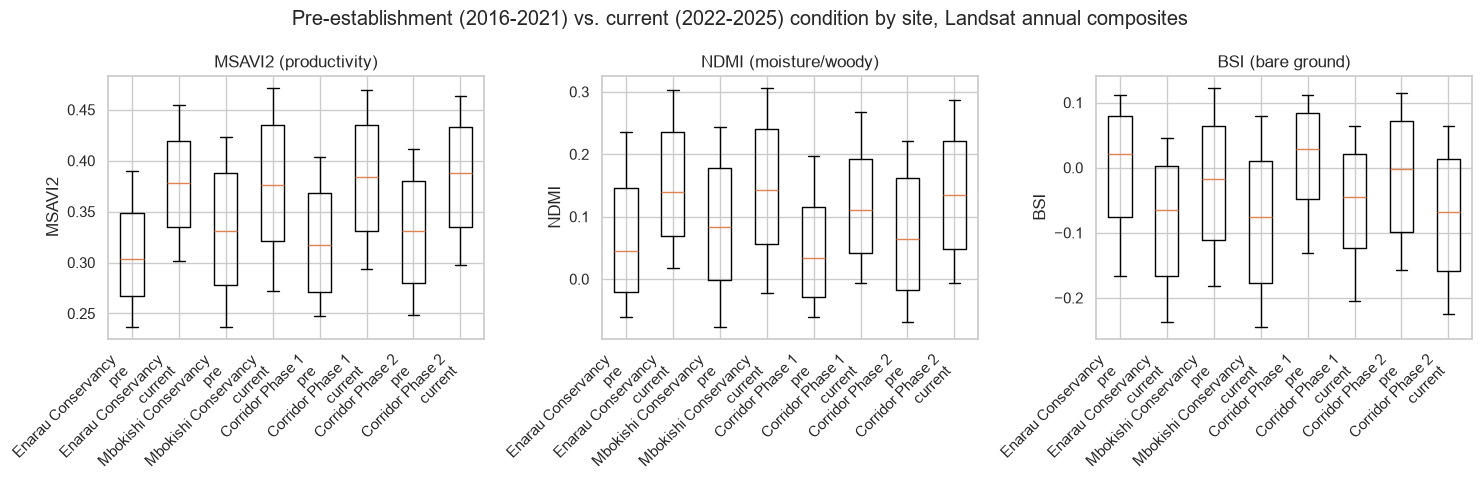

In [9]:
def build_boxplot_stats(df: pd.DataFrame, value_prefix: str) -> list[dict]:
    """Build matplotlib bxp() stats dicts directly from already-computed spatial percentiles."""
    stats = []
    for _, row in df.iterrows():
        stats.append(
            {
                "label": f"{SITE_LABELS[row['site_id']]}\n{row['period']}",
                "med": row[f"{value_prefix}_median"],
                "q1": row[f"{value_prefix}_p25"],
                "q3": row[f"{value_prefix}_p75"],
                "whislo": row[f"{value_prefix}_p10"],
                "whishi": row[f"{value_prefix}_p90"],
                "fliers": [],
            }
        )
    return stats


BOXPLOT_PERIODS = ["pre", "current"]
BOXPLOT_METRICS = [
    ("MSAVI2", "MSAVI2 (productivity)"),
    ("NDMI", "NDMI (moisture/woody)"),
    ("BSI", "BSI (bare ground)"),
]

period_subset = landsat_period[landsat_period["period"].isin(BOXPLOT_PERIODS)].copy()
period_subset["site_id"] = pd.Categorical(period_subset["site_id"], categories=SITE_ORDER, ordered=True)
period_subset["period"] = pd.Categorical(period_subset["period"], categories=BOXPLOT_PERIODS, ordered=True)
period_subset = period_subset.sort_values(["site_id", "period"])

fig, axes = plt.subplots(1, len(BOXPLOT_METRICS), figsize=(15, 5))
for ax, (metric, label) in zip(axes, BOXPLOT_METRICS):
    ax.bxp(build_boxplot_stats(period_subset, metric), showfliers=False)
    ax.set_title(label)
    ax.set_ylabel(metric)
    for tick_label in ax.get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_horizontalalignment("right")

fig.suptitle("Pre-establishment (2016-2021) vs. current (2022-2025) condition by site, Landsat annual composites")
fig.tight_layout()
fig.savefig(config.PLOTS_DIR / "pre_vs_current_condition_boxplots.png", dpi=200, bbox_inches="tight")

## Plot 6 -- LandTrendr disturbance/recovery area by site (NBR run vs. MSAVI2 run)

Direct numeric complement to the LandTrendr disturbance/recovery rasters: the rasters show
*where* on the ground disturbance/recovery occurred, this shows the *aggregate extent* per site
so relative magnitude across the four sites doesn't have to be eyeballed off a map. Rows compare
the two independent LandTrendr segmentations (dry-season NBR, wet-season MSAVI2 -- plan Sec.11.6)
side by side rather than summing them, since they come from separate segmentations of different
indices and a combined total wouldn't correspond to any single coherent measurement (see
`notes.md`). Columns split the full 1984-2025 record from the plan's own "recent window"
breakdown -- whether disturbance is concentrated in 2016-2025 or has accelerated further within
2022-2025. Y-axes are shared per column so the NBR-run and MSAVI2-run rows are directly
comparable in scale.

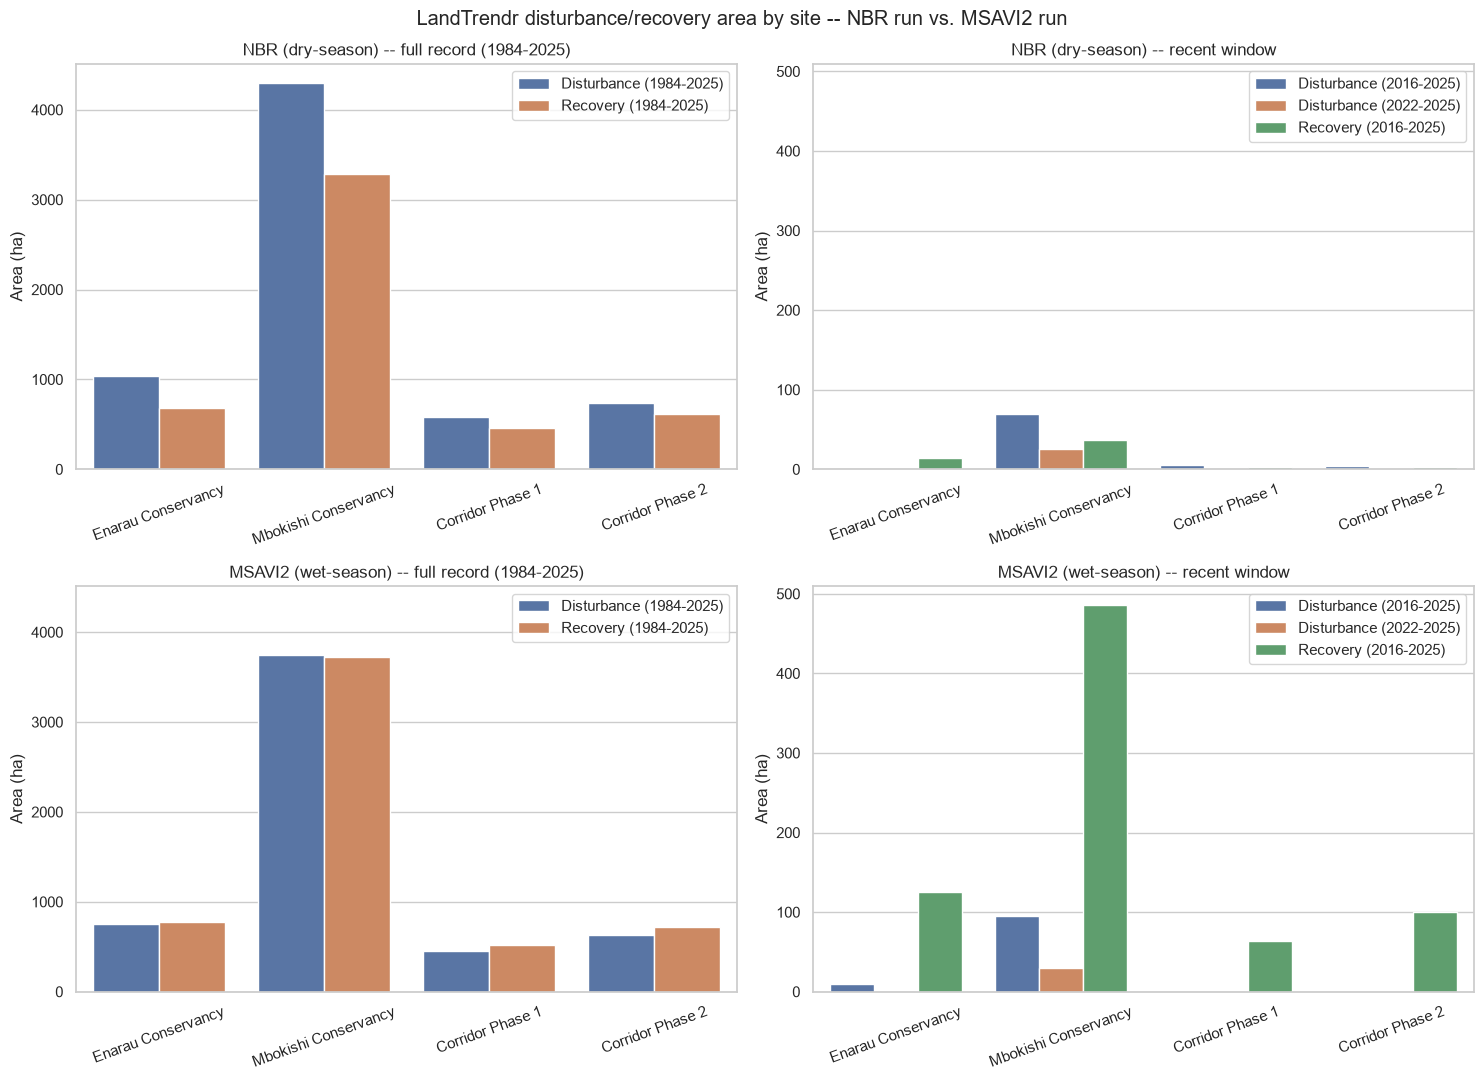

In [10]:
CHANGE_TYPE_LABELS = {
    "disturbance_full": "Disturbance (1984-2025)",
    "recovery_full": "Recovery (1984-2025)",
    "disturbance_recent_2016_2025": "Disturbance (2016-2025)",
    "disturbance_recent_2022_2025": "Disturbance (2022-2025)",
    "recovery_recent_2016_2025": "Recovery (2016-2025)",
}
LANDTRENDR_RUNS = {
    "nbrseg": ("NBR (dry-season)", landtrendr_nbrseg_summary),
    "msavi2seg": ("MSAVI2 (wet-season)", landtrendr_msavi2seg_summary),
}
RECENT_CHANGE_TYPES = [
    "disturbance_recent_2016_2025",
    "disturbance_recent_2022_2025",
    "recovery_recent_2016_2025",
]
site_name_order = [SITE_LABELS[s] for s in SITE_ORDER]

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharey="col")

for row, (run_key, (run_label, run_df)) in enumerate(LANDTRENDR_RUNS.items()):
    run_df = run_df.copy()
    run_df["site_name"] = run_df["site_id"].map(SITE_LABELS)
    run_df["change_label"] = run_df["change_type"].map(CHANGE_TYPE_LABELS)

    full_record = run_df[run_df["change_type"].isin(["disturbance_full", "recovery_full"])]
    recent = run_df[run_df["change_type"].isin(RECENT_CHANGE_TYPES)]

    sns.barplot(
        data=full_record, x="site_name", y="area_ha_sum", hue="change_label",
        order=site_name_order, ax=axes[row, 0],
    )
    axes[row, 0].set_title(f"{run_label} -- full record (1984-2025)")
    axes[row, 0].set_xlabel("")
    axes[row, 0].set_ylabel("Area (ha)")
    axes[row, 0].legend(title=None)
    axes[row, 0].tick_params(axis="x", rotation=20)

    sns.barplot(
        data=recent, x="site_name", y="area_ha_sum", hue="change_label",
        order=site_name_order, ax=axes[row, 1],
    )
    axes[row, 1].set_title(f"{run_label} -- recent window")
    axes[row, 1].set_xlabel("")
    axes[row, 1].set_ylabel("Area (ha)")
    axes[row, 1].legend(title=None)
    axes[row, 1].tick_params(axis="x", rotation=20)

fig.suptitle("LandTrendr disturbance/recovery area by site -- NBR run vs. MSAVI2 run")
fig.tight_layout()
fig.savefig(config.PLOTS_DIR / "landtrendr_area_by_site_nbr_vs_msavi2.png", dpi=200, bbox_inches="tight")

## Plot 7 -- Annual rainfall (CHIRPS)

Rainfall-confounding context (plan Sec.16.D): if Plots 1-4 show every site declining in the same
year, cross-check it against a rainfall dip here before reading it as localized degradation.
Uses `eetools.visualization.plots.plot_single_metric_annually` directly rather than a
hand-rolled line plot.

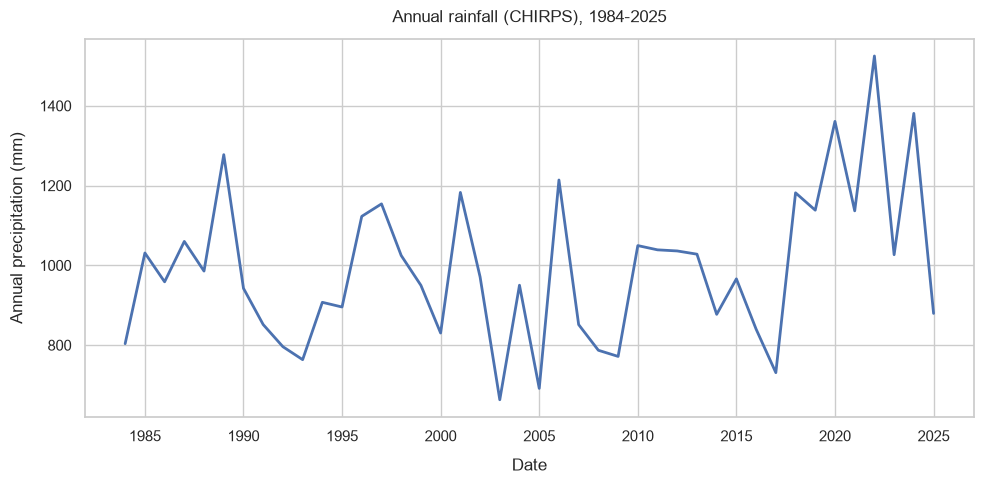

In [11]:
fig, ax = plot_single_metric_annually(
    chirps_annual,
    title="Annual rainfall (CHIRPS), 1984-2025",
    date_col="date",
    metric_col="precipitation",
)
ax.set_ylabel("Annual precipitation (mm)")
fig.savefig(config.PLOTS_DIR / "chirps_annual_rainfall_1984_2025.png", dpi=200, bbox_inches="tight")

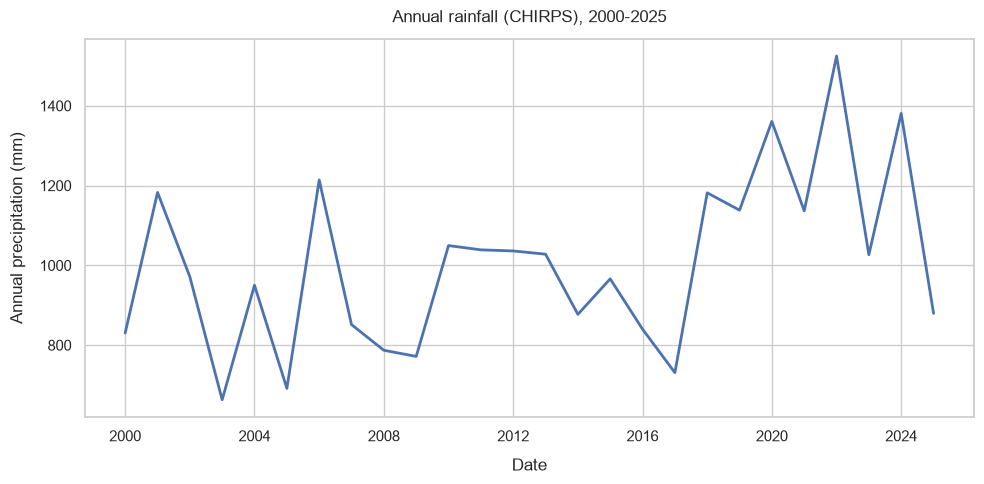

In [12]:
chirps_annual_2000_2025 = chirps_annual[(chirps_annual.year >= 2000) & (chirps_annual.year <= 2025)].copy()

fig, ax = plot_single_metric_annually(
    chirps_annual_2000_2025,
    title="Annual rainfall (CHIRPS), 2000-2025",
    date_col="date",
    metric_col="precipitation",
)
ax.set_ylabel("Annual precipitation (mm)")
fig.savefig(config.PLOTS_DIR / "chirps_annual_rainfall_2000_2025.png", dpi=200, bbox_inches="tight")

## Notes & next steps

- The 1980s-90s dry-season data gaps visible in Plots 1-4 (breaks in the line) are real --
  some Landsat-5-only dry-season windows have zero cloud-free scenes over this ~89 km² AOI --
  not a plotting artifact.
- Plot 4 covers MSAVI2 only; the same `build_relative_anomaly` helper works unchanged for NDMI or
  BSI if a reviewer wants the moisture/bare-ground anomaly too.
- Plot 5's boxes are built from spatial percentiles already computed during the zonal-statistics
  export (median/p10/p25/p75/p90), not raw per-pixel values -- this notebook makes no Earth
  Engine calls, matching Objective 1's own plotting notebook.
- Plot 6 compares the two independent LandTrendr runs (NBR, MSAVI2) side by side rather than
  merging them into one chart -- reading a site's MSAVI2-run event through its co-fitted
  NBR/NDMI/BSI FTV trajectory (plan Sec.11.6's interpretation table) requires the per-pixel
  fitted-trajectory rasters, not this site-level area summary; this notebook doesn't (and can't,
  without a new zonal-statistics export) show that per-pixel directional-agreement check.
- The LandTrendr fitted-trajectory rasters (`LT_NBRseg_*_fitted_dry_*` /
  `LT_MSAVI2seg_*_fitted_wet_*`) have no corresponding table in `outputs/tables/` -- they were
  exported as rasters only (no zonal-statistics reduction was built for them), so there's no plot
  for them here. A future addition would need the LandTrendr notebook to export a per-site
  summary of those stacks first (e.g. mean fitted value per year/site) before a trend-over-time
  chart could be added here.
- HLS (2015-present) and Sentinel-2 (2017-present, red-edge NDRE/CIred_edge) tables are already
  in `outputs/tables/` for a future fine-scale or recent-period follow-up, kept separate per the
  plan's own sensor-separate interpretation guidance (Sec.16.C).
- Cross-check any pattern seen here against the LandTrendr disturbance/recovery rasters and
  Objective 1's Dynamic World transitions before finalizing a reporting claim (plan Sec.15/18).